###### 3/28/2026
## Neural Network Modeling for Climate Data


#### Variable and Parameters Names
 - Climate = the original data set (146 observations with 19 parameters)
 - months = Monthly climate data
 - J.D = Jan - Dec (Yearly temp)
 - N.D = Dec - Nov (Meteorological Year)
 - DJF = Dec, Jan, Feb
 - MAM = Mar, Apr, May
 - JJA = June, July, Aug
 - SON = Sep, Oct, Nov

In [1]:
# Libraries for use
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from dataclasses import dataclass
from scipy import stats
import json
import random

torch.set_num_threads(4)

# Setting Seed. 
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Cross Validation -- Rolling Origin CV with Profit Package


device_gpu = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_cpu = torch.device('cpu')

if hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    print('xpu')
else:
    device = torch.device("cpu")
    print('cpu')

# Setting graph style:
plt.style.use('seaborn-v0_8-whitegrid')

cpu


## Initial Loading and processing of data:

In [2]:
## Setting Parameter Values Here
## -------- This will be used with the Window function below. 
@dataclass
class param:
    start: int = 0 # start of window
    length: int = 24 # length of training window
    lead: int = 24 # Length of target window
    batch: int = 24 # Alternative to the Lead
    test: int = 120 # Testing length for protected 'test' data that is unseen by the model. 

prm = param()
print(prm)

param(start=0, length=24, lead=24, batch=24, test=120)


In [3]:
from pathlib import Path

candidate_paths = [
    Path("GLB.Ts+dSST.csv"),
    Path("./GLB.Ts+dSST.csv"),
    Path("/mnt/data/GLB.Ts+dSST.csv")
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    matches = list(Path(".").glob("**/GLB.Ts+dSST.csv"))
    if matches:
        csv_path = matches[0]

if csv_path is None:
    raise FileNotFoundError("Could not find GLB.Ts+dSST.csv in the current folder or common fallback locations.")

Climate = pd.read_csv(csv_path, skiprows=1, na_values="***")
Climate = Climate.drop(len(Climate) - 1)
# Climate = Climate.drop(0) While consistent, this will break the code, as the remaining data is no longer divisible by 24

## Cleaning Missing Values, by averaging over the data we have.
labelsDJ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
labelsDJF = ['Jan', 'Feb']

Climate.at[0, "D-N"] = Climate.loc[0, labelsDJ].mean().round(2)
Climate.at[0, "DJF"] = Climate.loc[0, labelsDJF].mean().round(2)

Climate["D-N"] = pd.to_numeric(Climate["D-N"], errors="coerce")
Climate["DJF"] = pd.to_numeric(Climate["DJF"], errors="coerce")

print(f"Loaded climate file from: {csv_path}")
print(Climate.head())
print(Climate.columns.tolist())
Climate.tail()


Loaded climate file from: Data\GLB.Ts+dSST.csv
   Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov  \
0  1880 -0.19 -0.25 -0.10 -0.17 -0.11 -0.22 -0.19 -0.11 -0.15 -0.24 -0.23   
1  1881 -0.21 -0.15  0.02  0.04  0.05 -0.20 -0.01 -0.04 -0.16 -0.22 -0.19   
2  1882  0.15  0.13  0.04 -0.18 -0.15 -0.24 -0.17 -0.08 -0.15 -0.24 -0.17   
3  1883 -0.30 -0.37 -0.13 -0.19 -0.18 -0.07 -0.08 -0.14 -0.22 -0.11 -0.25   
4  1884 -0.14 -0.09 -0.37 -0.40 -0.34 -0.35 -0.31 -0.28 -0.27 -0.25 -0.34   

    Dec   J-D   D-N   DJF   MAM   JJA   SON  
0 -0.18 -0.18 -0.18 -0.22 -0.13 -0.17 -0.21  
1 -0.08 -0.10 -0.10 -0.18  0.04 -0.08 -0.19  
2 -0.37 -0.12 -0.09  0.07 -0.10 -0.16 -0.19  
3 -0.12 -0.18 -0.20 -0.35 -0.17 -0.10 -0.19  
4 -0.31 -0.29 -0.27 -0.11 -0.37 -0.31 -0.29  
['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
141,2021,0.82,0.64,0.89,0.76,0.79,0.85,0.92,0.81,0.93,0.99,0.93,0.88,0.85,0.84,0.75,0.81,0.86,0.95
142,2022,0.91,0.89,1.05,0.84,0.84,0.92,0.94,0.95,0.89,0.97,0.73,0.80,0.90,0.90,0.89,0.91,0.94,0.87
143,2023,0.88,0.97,1.23,0.99,0.94,1.09,1.20,1.19,1.48,1.34,1.41,1.37,1.17,1.13,0.88,1.06,1.16,1.41
144,2024,1.25,1.45,1.39,1.31,1.15,1.21,1.20,1.29,1.24,1.33,1.30,1.26,1.28,1.29,1.36,1.28,1.23,1.29
145,2025,1.38,1.26,1.37,1.25,1.08,1.06,1.02,1.18,1.25,1.20,1.21,1.06,1.19,1.21,1.30,1.23,1.09,1.22


## Handling the data

In [4]:
climate = Climate[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].copy()
climate.head()

## Indexing the time for future use.
start_year = int(Climate["Year"].min())
end_year = int(Climate["Year"].max())

time_index_month = pd.date_range(
    start=f"{start_year}-01-01",
    periods=len(climate) * 12,
    freq="MS"
)

time_index_year = pd.date_range(
    start=f"{start_year}-01-01",
    periods=len(Climate),
    freq="YS"
)

print(time_index_month[:5])
print(time_index_month[-5:])
print(len(time_index_month), climate.size)


DatetimeIndex(['1880-01-01', '1880-02-01', '1880-03-01', '1880-04-01',
               '1880-05-01'],
              dtype='datetime64[us]', freq='MS')
DatetimeIndex(['2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
               '2025-12-01'],
              dtype='datetime64[us]', freq='MS')
1752 1752


### Standardizing the data

In [5]:
## Normalizing the data and converting to a tensor.
months = climate.copy()
years = Climate["Year"].copy()
averages = pd.to_numeric(Climate["J-D"], errors="coerce")

train_limit = len(months) - prm.test

train_mean = np.nanmean(months.iloc[:train_limit].values)
train_std = np.nanstd(months.iloc[:train_limit].values)

standard = (months - train_mean) / train_std
month = torch.tensor(standard.values, dtype=torch.float32)
y = torch.tensor(((averages - np.nanmean(averages)) / np.nanstd(averages)).values, dtype=torch.float32)
year = torch.tensor(years.values)

## Creating a function to backtransform:
def backtransform(x, mean=train_mean, std=train_std):
    back = x * std + mean
    return back

print(train_mean)
print(train_std)

-0.24330128205128204
0.1516014900758833


## 'Sliding Window' Feed-Forward Neural Network (FFNN) Neural Network

In [6]:
## The data was placed into a DataFrame with time and the standardized months for easier use in the Networks.
flat_df = pd.DataFrame({
    "time": time_index_month,
    "original": standard.values.flatten(),
    "non_standard": months.values.flatten()
})  # From standardizing above.

flat_df["original"] = pd.to_numeric(flat_df["original"], errors="coerce")
flat_df["non_standard"] = pd.to_numeric(flat_df["non_standard"], errors="coerce")
flat_df = flat_df.dropna(subset=["original"]).reset_index(drop=True)

## To check if the data is actually standardized, you can use the line below:
# print(flat_df.original.mean(), flat_df.original.std())

## The function below is a custom function for a moving window or to allow for 'forward-feeding' of the data.
# The window function will spit out lagged and lead data based on outside indexing.
# It should take the data from a given starting point, and spit out training data of length = length,
# and target data of length = lead of data just beyond what the training data is set at.

def window(timeseries, start, length, lead):
    lagged = timeseries.iloc[start:start + length]
    future = start + length
    leads = timeseries.iloc[future:future + lead]
    return (
        torch.tensor(lagged.values, dtype=torch.float32),
        torch.tensor(leads.values, dtype=torch.float32)
    )

print(flat_df.head())
print(flat_df.tail())
print(len(flat_df))


        time  original  non_standard
0 1880-01-01  0.351588         -0.19
1 1880-02-01 -0.044186         -0.25
2 1880-03-01  0.945250         -0.10
3 1880-04-01  0.483513         -0.17
4 1880-05-01  0.879287         -0.11
           time  original  non_standard
1747 2025-08-01  9.388439          1.18
1748 2025-09-01  9.850175          1.25
1749 2025-10-01  9.520363          1.20
1750 2025-11-01  9.586326          1.21
1751 2025-12-01  8.596890          1.06
1752


#### Creating Framework

In [7]:
## Creating the NN framework
class SlidingWindow(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(24, 16),
            nn.LeakyReLU(),
            nn.Dropout(.2),
            nn.Linear(16, 12),
            nn.LeakyReLU(),
            nn.Dropout(.1),
            nn.Linear(12, prm.lead)
        )

    def forward(self, x):
        return self.network(x)

tsmodel = SlidingWindow()
print(tsmodel)


SlidingWindow(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=12, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=12, out_features=24, bias=True)
  )
)


### Creating a function to call the 'training process' for Tuning

In [8]:
# Inidializing loss lists 
all_mse_train = []
all_mse_test = []
all_mae_train = []
all_mae_test = []

def SlidingWind(learning = .001, epoch_max = 40, reset_loss = False, evaluate = True):
    backor, backpr, slid_prediction = None, None, None
    global all_mse_train, all_mse_test, all_mae_train, all_mae_test
    if reset_loss == True: 
        all_mse_train = []
        all_mse_test = []
        all_mae_train = []
        all_mae_test = []
        
    # need to create an outside value for past lag and lead. 
    start = prm.start
    length = prm.length
    lead = prm.lead
    
    ## Choose loss and optimizer
    tsmodel = SlidingWindow() # Setting this allows the model to reset before training. 
    criterion = nn.SmoothL1Loss() #Huber Loss
    optimizer = optim.Adam(tsmodel.parameters(), lr=learning)

    ## Begin for loop for training
    for epoch in range(epoch_max):
        running_loss = 0.0
        pred = []
    
        ## Iterate sliding window
        tsmodel.train()
        ## subtracting prm.test should remove the last set of data to be trained against. This, therefore, does not see the last "10" years 
        ## -(24 + 24 + 120) + 24 for the last target. 
        for i in range(0,len(flat_df.original) - lead - length - prm.test, lead):  
            lags, leads = window(flat_df.original, i, length, lead)
            lags_dim = lags.view(1, -1) # resetting the dimensions to work with the NN. 
            leads_dim = leads.view(1, -1)
        
            ## Forward pass
            optimizer.zero_grad()
            outputs = tsmodel(lags_dim)
            loss = criterion(outputs, leads_dim)

            ## Backward pass
            loss.backward()
            optimizer.step()
    
            ## record loss increase lead indexing
            running_loss += loss.item()

            #print(f'Runnig Loss: {running_loss:.3f}')

    if evaluate == True:
        ## finding predictions
        tsmodel.eval()
        pred = []

        with torch.no_grad():
            for i in range(0,len(flat_df.original) - length, lead): 
                lags, __ = window(flat_df.original, i, length, lead)
                output = tsmodel(lags)
                pred.append(output)

        # Condensing the predictions into one array and backtransforming it
        # It should be set at -24 as we do not want to forecast the first 2 years. 
        slid_prediction = (np.concatenate(pred))

        ## With backtransforming
        backor = backtransform(flat_df.original)  
        backpr = backtransform(slid_prediction)

        ## Checking MSE and MAE of the last 10 years. 
        mse_train = (np.mean((backor[prm.lead:-prm.test*10] - backpr[:-prm.test*10])**2))
        mse_test = (np.mean((backor[-prm.test*10:] - backpr[-prm.test*10:])**2))
        mae_train = np.mean(abs(backor[prm.lead:-prm.test*10] - backpr[:-prm.test*10]))
        mae_test = (np.mean(abs(backor[-prm.test*10:] - backpr[-prm.test*10:])))
        all_mse_train.append(mse_train)
        all_mse_test.append(mse_test)
        all_mae_train.append(mae_train)
        all_mae_test.append(mae_test)

    return tsmodel, backor, backpr, slid_prediction


### Performing tuning for Epochs and Learning Rate

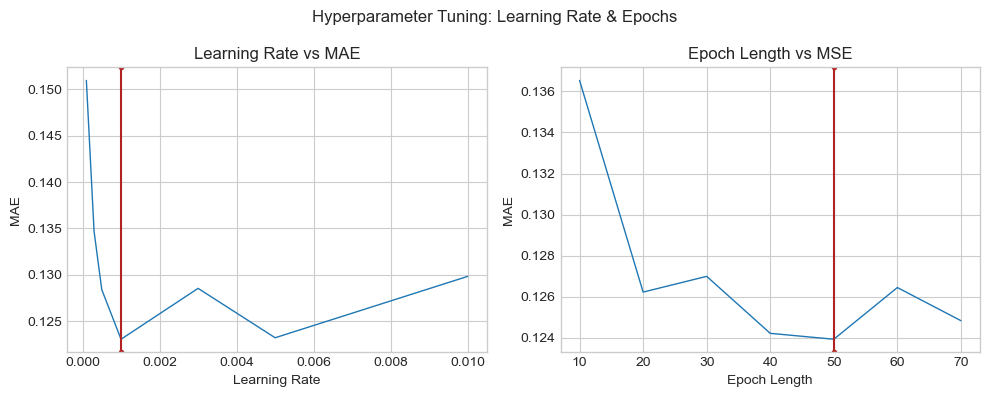

In [9]:
## Running hyperparameter tuning for learning rate and epochs. 
## Here the seed should iterate through a consistent set of seeds
iterations = 20
learning = [.01,.005,.003,.001,.0005,.0003,.0001]     
epochs = range(10,80,10)   
## Resetting training loss
boot_mae_learning = np.zeros((iterations,len(learning)))
boot_mae_epochs = np.zeros((iterations,len(epochs)))
all_mse_train = []
all_mse_test = []
all_mae_train = []
all_mae_test = []

for j in range(iterations):
    ## Running through various learning rates
    for i in range(0,len(learning)):
        SlidingWind(learning = learning[i])
        boot_mae_learning[j, i] = all_mae_test[-1]

best_learning = learning[np.argmin(np.mean(boot_mae_learning, 0))]

## Resetting training loss
all_mse_train = []
all_mse_test = []
all_mae_train = []
all_mae_test = []

for j in range(iterations):
    for i in range(0,len(epochs)):
        SlidingWind(learning = best_learning, epoch_max = epochs[i])
        boot_mae_epochs[j,i] = all_mae_test[-1]

best_epoch = epochs[np.argmin(np.mean(boot_mae_epochs, 0))]

# Setting graphic features for below
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Hyperparameter Tuning: Learning Rate & Epochs")

ax[0].plot(learning, np.mean(boot_mae_learning,0), linewidth = 1)
ax[0].axvline(best_learning, color = "firebrick", marker = '.', label = f"Best: {best_learning}")
ax[0].set_title("Learning Rate vs MAE")
ax[0].set_ylabel("MAE")
ax[0].set_xlabel("Learning Rate")

ax[1].plot(epochs, np.mean(boot_mae_epochs,0), linewidth = 1)
ax[1].axvline(best_epoch, color = "firebrick", marker = '.', label = f"Best: {best_epoch}")
ax[1].set_title("Epoch Length vs MSE")
ax[1].set_ylabel("MAE")
ax[1].set_xlabel("Epoch Length")
plt.tight_layout()
plt.show()


#### Running optimized model

Mean Training/Testing loss on 20 iterations
Train MSE: 0.018 MAE: 0.103
Test MSE: 0.025 MAE: 0.124


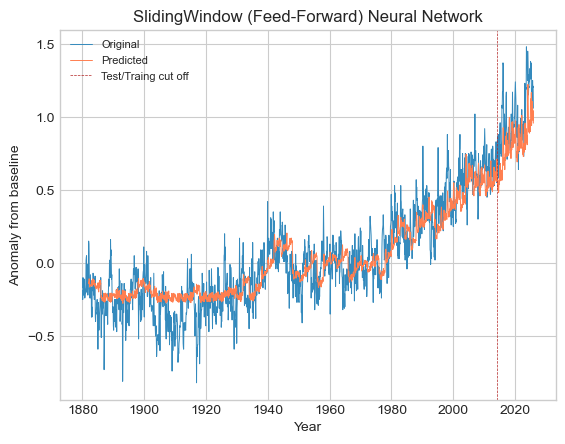

In [10]:
## Creating a large loop for Forward Chaining. 
iteration = 20
boot_mae_train = []
boot_mae_test = []
boot_mse_test = []
boot_mse_train = []
for _ in range(0,iteration):
    SlidingWind(learning = best_learning, epoch_max = 40, reset_loss = True, evaluate = True)
    boot_mae_train.append(all_mae_train[-1])
    boot_mae_test.append(all_mae_test[-1])
    boot_mse_train.append(all_mse_train[-1])
    boot_mse_test.append(all_mse_test[-1])

## Printing a single run:
_, backor, backpr, slid_prediction = SlidingWind(learning = best_learning, epoch_max = 10, reset_loss = True, evaluate = True)
print(f'Mean Training/Testing loss on {iteration} iterations')
print(f'Train MSE: {np.mean(boot_mse_train):.3f} MAE: {np.mean(boot_mae_train):.3f}')
print(f'Test MSE: {np.mean(boot_mse_test):.3f} MAE: {np.mean(boot_mae_test):.3f}')
plt.plot(flat_df.time, backor, color = "#348ABD", linewidth = .7, label = "Original")
plt.plot(flat_df.time.loc[prm.length:len(flat_df.original)], backpr, color = "coral", linewidth = .7, label = "Predicted") 
plt.title("SlidingWindow (Feed-Forward) Neural Network")
plt.axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
            color = "firebrick", linewidth = .5, linestyle = "--") 
plt.ylabel("Anomaly from baseline")
plt.xlabel("Year")
plt.legend(fontsize=8)
plt.show()


#### Learning rate
I tested the learning rate at various levels of .1, .01, .001, and .0001 to start. Setting the learning rate too high or too low causes issues with convergence. If the rate is set to .1, the model overcorrects the weights and struggles to converge. The graph forms a wild curve that only somewhat stablizes around the baseline of 1951 - 1980, before it again explodes. On the other hand, too low a learning rate, such as .0001 does not allow enough movement of the weights for the model to converge within a reasonable time. When global temperatures began increasing in the 1990s, the model struggled to adjust. Choosing a value between .01 and .001 allows the model to converge well. The rate .001 to .005 seemes to fit the data a little better than .01. You can see some of these graphs by setting the first loop to be for i in range(0,4) and setting learning[i] instead of learning[2]

The number of epochs was equally important. Too small an epoch does not allow the model to find stable weights, but too large epochs can cause them to overcorrect and do not necessarily lead to better results. It can overtrain and 'memorize' the data. Setting the epoch around 60 seemed to produce the best results. This can be seen by setting the epoch in range(epochs[i]). I usually turned off the graphs when I did this. You can see that the MSE and MAE are better around 30 - 40 epochs, then either stabilize or worsen beyond that. 

With these values set, the model shows a very strong prediction on the test data. The typical MSE is around .025 and MAE = .108. Including values such as nn.Dropout does not improve the model and, in some cases, can even make it worse. As the fit is quite good, I did not see a need to change the parameters. There is a chance that this model, as it is, is suffering from some data leakage. The loop is increasing the training data by prm.lead for each iteration. The range may be incorrect, and only 23 of the next 24 target data are unknown to the model. This may give the model too much 'insight' into the lead data. I have not tested this to ensure that it is true. 

In [11]:
## Creating the confidence interval. 
mae_conf = pd.DataFrame(boot_mae_test)
print(f'Bootstrapped Confidence interval for MSE on testing data:')
print(f'({mae_conf.quantile(.05).values[0]:.3f},{mae_conf.quantile(.95).values[0]:.3f})');


Bootstrapped Confidence interval for MSE on testing data:
(0.112,0.139)


#### Confidence Interval 
I would not run this on the CPU if you do not have to. It took ~ 10 minutes on my machine for 100 iterations. (1000 would be more ideal, maybe I will do this when I need to head up my laptop to trick the AC into turning on for my classroom). However, the confidence interval is very tight and much lower than that of SARIMA. I would also like to run the MAE, which was .473  for SARIMA and seems to be around .11 for NN. 

I will also try to get this to work in parellel if I have time. 

#### Ploting a single graph for SlidingWindow NN with diagnostics

In [12]:
## finding predictions
## Resetting the SEED
torch.manual_seed(SEED)

tsmodel, backor , backpr ,_ = SlidingWind(learning = .001, epoch_max = 60, reset_loss = True, evaluate = False)
tsmodel.eval()
pred = []

with torch.no_grad():
    for i in range(0,len(flat_df.original) - prm.length, prm.lead): 
        lags, __ = window(flat_df.original, i, prm.length, prm.lead)
        output = tsmodel(lags)
        pred.append(output)


# Condensing the predictions into one array and backtransforming it
# It should be set at -24 as we do not want to forecast the first 2 years. 
slid_prediction = (np.concatenate(pred))
len(slid_prediction) - len(flat_df.original)

-24

In [13]:
len(flat_df.time.loc[prm.length:len(flat_df.original)])
#len(slid_prediction)
len(flat_df.original)
prm.length

24

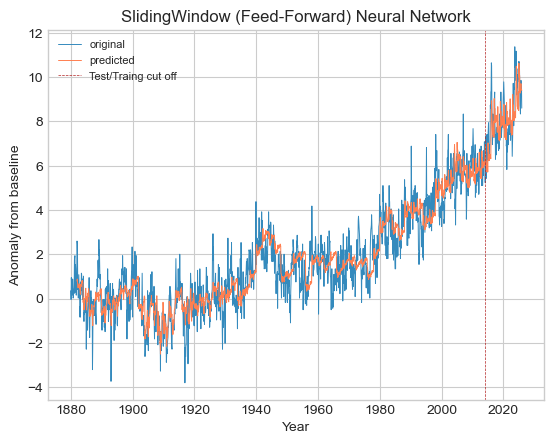

In [14]:
## plotting the data
## Neither data has been back transformed
plt.plot(flat_df.time, flat_df.original, color = "#348ABD", linewidth = .7, label = "original")
plt.plot(flat_df.time.loc[prm.length:prm.length + len(slid_prediction)], slid_prediction, color = "coral", linewidth = .7, label = "predicted")
plt.title("SlidingWindow (Feed-Forward) Neural Network")
plt.axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
                color = "firebrick", linewidth = .5, linestyle = "--") 
plt.ylabel("Anomaly from baseline")
plt.xlabel("Year")
plt.legend(fontsize=8)
plt.show()

Train MSE: 0.018
Test MSE: 0.022


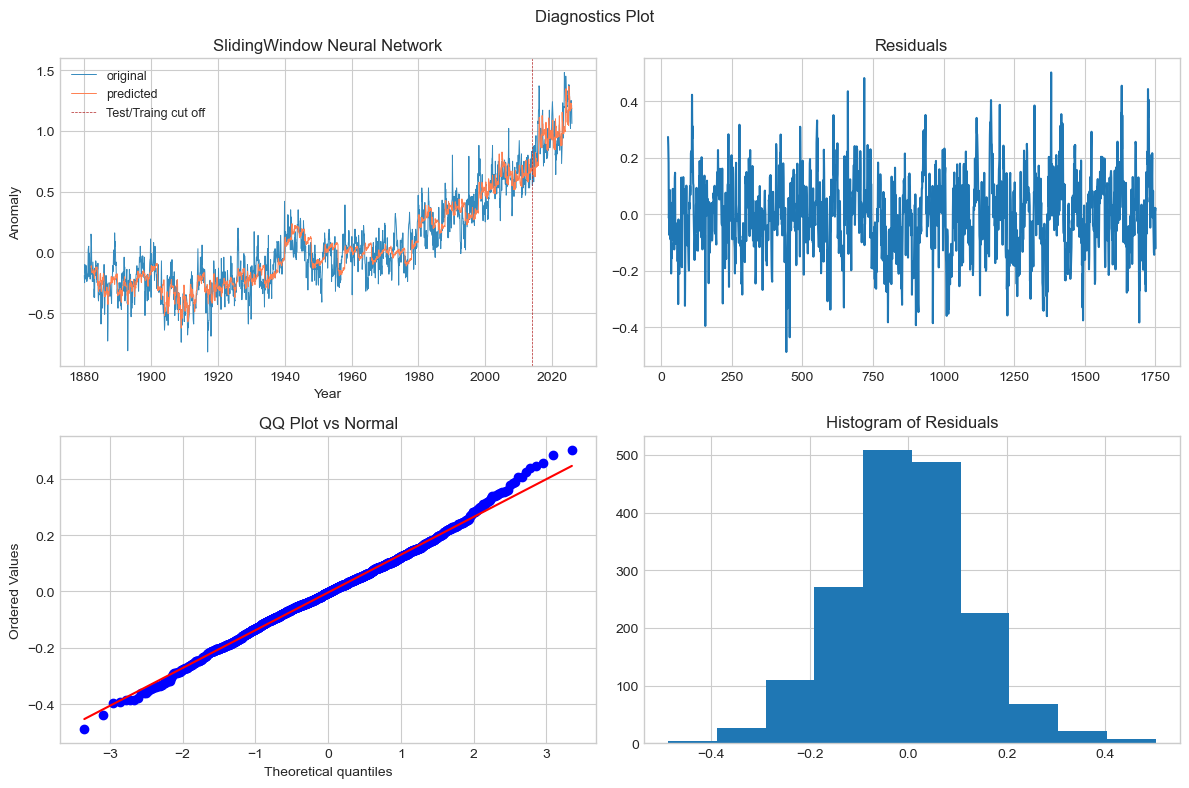

In [15]:
## With backtransforming
backor = backtransform(flat_df.original)  
backpr = backtransform(slid_prediction)
residuals = backor[prm.lead:] - backpr

mse_train = np.mean((backor[prm.lead:-120] - backpr[:-120])**2)
mse_test = np.mean((backor[-120:] - backpr[-120:])**2)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Diagnostics Plot")

print(f'Train MSE: {mse_train:.3f}')
print(f'Test MSE: {mse_test:.3f}')
ax[0,0].plot(flat_df.time, backor, color = "#348ABD", linewidth = .7, label = "original")
ax[0,0].plot(flat_df.time.loc[prm.length:len(flat_df.original)], backpr, color = "coral", linewidth = .7, label = "predicted") 
ax[0,0].set_title("SlidingWindow Neural Network")
ax[0,0].axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
            color = "firebrick", linewidth = .5, linestyle = "--") 
ax[0,0].set_ylabel("Anomaly")
ax[0,0].set_xlabel("Year")
ax[0,0].legend(fontsize=9)

ax[0,1].plot(residuals)
ax[0,1].set_title("Residuals")
ax[1,1].hist(residuals)
ax[1,1].set_title("Histogram of Residuals")
stats.probplot(residuals, dist="norm", plot=ax[1, 0])
ax[1,0].set_title("QQ Plot vs Normal")

plt.tight_layout()
plt.show()


In [16]:
## calculating means squared error:
mse = np.mean((backor.loc[24:1752] - backpr)**2)
mae = np.mean(abs(backor.loc[24:1752] - backpr))
print(f'Mean Squared Error: {mse:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')

Mean Squared Error: 0.0179
Mean Absolute Error: 0.1041


#### From here, I added some scripts to allow for true future predictions

In [17]:
## Attempting to feed in future data into the NN, aiming for the last 24
## Don't Run this multiple times, rerun the initial pred function first. 
tsmodel.eval()

with torch.no_grad():
    final = len(flat_df.original)
    lags, __ = window(flat_df.original, final - prm.length, prm.length, 0)
    forcast = tsmodel(lags)
    pred.append(forcast)

    ## Running the prediction through the model to produce a further prediction. 
    forcast = tsmodel(forcast)
    pred.append(forcast)
slid_prediction = (np.concatenate(pred))


In [18]:
## resetting the time indexing to allow for future years. 
time_index_future = pd.date_range(start = "1882", end = "2030", freq = "MS")
time_index_future = time_index_future.drop(time_index_future[-1])
print(time_index_future)
len(backpr) - len(time_index_future)

DatetimeIndex(['1882-01-01', '1882-02-01', '1882-03-01', '1882-04-01',
               '1882-05-01', '1882-06-01', '1882-07-01', '1882-08-01',
               '1882-09-01', '1882-10-01',
               ...
               '2029-03-01', '2029-04-01', '2029-05-01', '2029-06-01',
               '2029-07-01', '2029-08-01', '2029-09-01', '2029-10-01',
               '2029-11-01', '2029-12-01'],
              dtype='datetime64[us]', length=1776, freq='MS')


-48

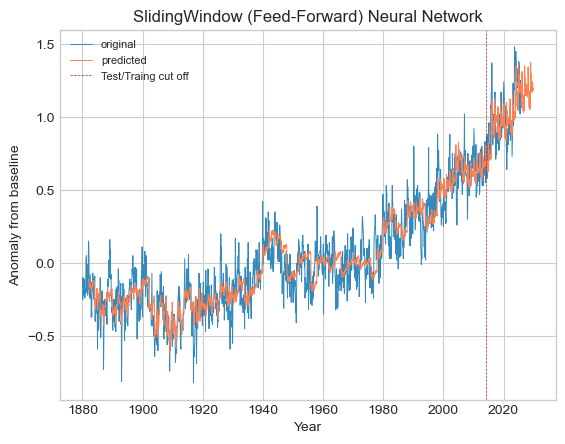

In [19]:
## With backtransforming
backor = backtransform(flat_df.original)
backpr = backtransform(slid_prediction)

plt.plot(flat_df.time, backor, color = "#348ABD", linewidth = .7, label = "original")
plt.plot(time_index_future, backpr, color = "coral", linewidth = .7, label = "predicted") 
plt.title("SlidingWindow (Feed-Forward) Neural Network")
plt.axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
                color = "firebrick", linewidth = .5, linestyle = "--") 
plt.ylabel("Anomaly from baseline")
plt.xlabel("Year")
plt.legend(fontsize=8)
plt.show()


## Conclution:
The model seems to do a decent job of producing a true 'prediction'. Interestingly, the model tends to want to predict a decrease in temperature anomalies. However, the 'prediction' the model produces heavily depends upon the initial random conditions set for the model. One run may show a decrease, while another may show a flat line (like SARIMA), or an increase. I would be interested to know if it is possible to average these to produce a more consistent estimate. 

## Attempting Pinball loss custom function for CI (Apparently Pytorch Forecast already has this?)
The idea behind this is to produce a pseudo confidence interval by estimating the 95th and 5th quantiles. 

In [20]:
## Creating a costume Pinball MSE combined loss. 
## Assuming 3 outputs MSE, Lower, Upper Quanitiles
def pinballHuber(output, lead, tau = .95):
    center = output[:,:,0]
    lower_q = output[:,:,1]
    upper_q = output[:,:,2]

    ## Huber loss
    huber_loss = nn.SmoothL1Loss()(center, lead)

    ## lower_q Loss
    tau_low = 1 - tau
    error_low = (lead - lower_q) # it may run faster when the error is calculated outside of the vectorization. 
    pin_low = torch.max(tau_low * error_low, (tau_low - 1) * error_low).mean()
    ## This works by switching the order of the error for "upper" vs "lower" quantiles. Here, I did this by switching the tau to be positive or negative. 

    ## Upper q loss
    error_high = (lead - upper_q)
    pin_high = torch.max(tau * error_high, (tau - 1) * error_high).mean()

    return(huber_loss + pin_low + pin_high)

In [21]:
## Creating the NN framework
## Resetting the SEED
torch.manual_seed(SEED)

batch = 24 # To hopefully control the output size easier. 
class PinballWindow(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(24,16),
            nn.LeakyReLU(),
            nn.Dropout(.2),
            nn.Linear(16,12),
            nn.LeakyReLU(),
            nn.Dropout(.1),
            ## Here, the output will contain three training columns
            ## MSE for point estimates, and "Pinball" for Quantile estimates
            ## :1 = point, :2 = lower, :3 = upper based on the custome loss. 
            nn.Linear(12,batch * 3)
         )

    def forward(self, x):
        x = self.network(x)
        return x.view(-1, batch, 3)


pinmodel = PinballWindow()
print(pinmodel)

PinballWindow(
  (network): Sequential(
    (0): Linear(in_features=24, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=12, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=12, out_features=72, bias=True)
  )
)


In [22]:
## Choose loss and optimizer
optimizer = optim.Adam(pinmodel.parameters(), lr=.001)

## Begin for loop
for epoch in range(60):
    running_loss = 0.0
    pred = []

    # need to create an outside value for past lag and lead. 
    start = 0
    length = prm.length
    lead = prm.batch
    
    ## Iterate sliding window
    pinmodel.train()
    for i in range(0,len(flat_df.original) - lead - length - prm.test, lead): 
        lags, leads = window(flat_df.original, i, length, lead)
        lags_dim = lags.view(1, -1)
        leads_dim = leads.view(1, -1)
        
        ## Forward pass
        optimizer.zero_grad()
        outputs = pinmodel(lags_dim)
        loss = pinballHuber(output = outputs, lead = leads_dim)

        ## Backward pass
        loss.backward()
        optimizer.step()
    
        ## record loss increase lead indexing
        running_loss += loss.item()
        
    #print(f'Runnig Loss: {running_loss:.3f}')
    

In [23]:
## finding predictions
pinmodel.eval()
pred = []

with torch.no_grad():
    for i in range(0,len(flat_df.original) - prm.length, prm.batch): 
        lags, __ = window(flat_df.original, i, prm.length, prm.batch)
        output = pinmodel(lags)
        pred.append(output)

# Condensing the predictions into one array and backtransforming it
pin_prediction = (np.concatenate(pred))
output.size()

torch.Size([1, 24, 3])

Train MSE: 0.019, MAE: 0.107
Test MSE: 0.025, MAE: 0.123


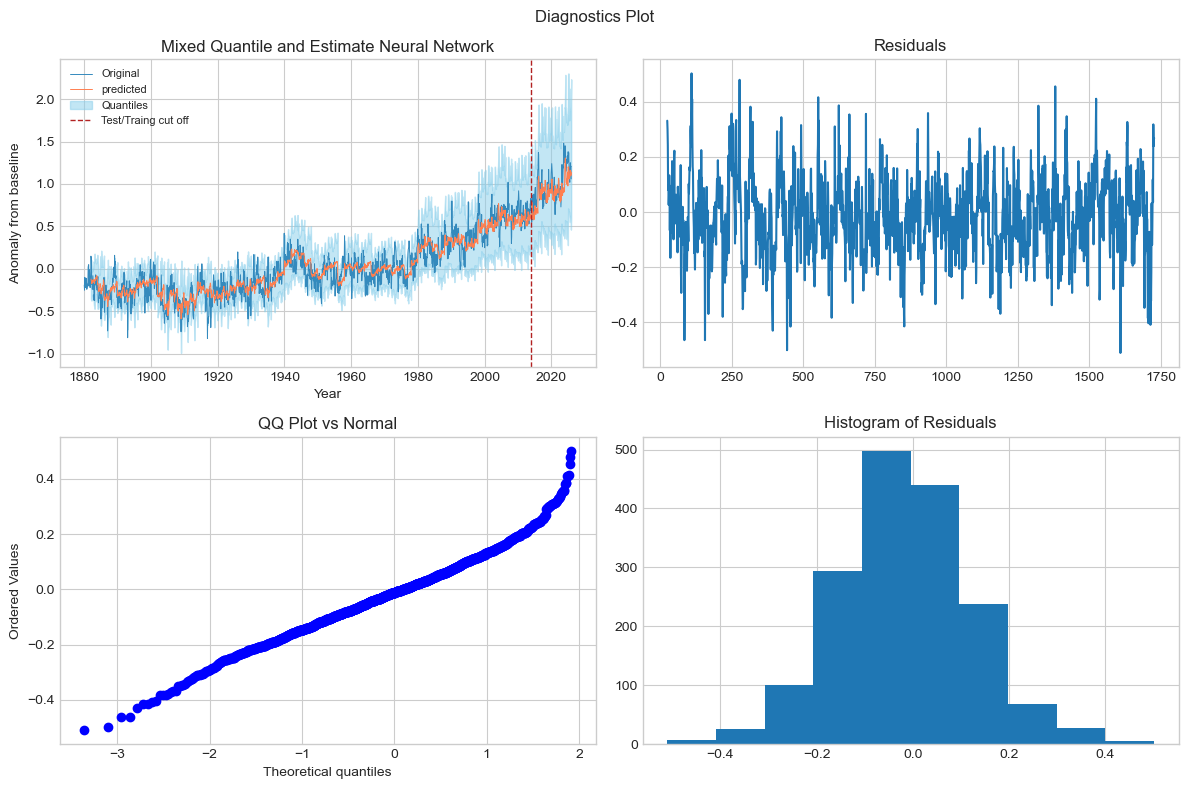

In [24]:
## Plotting and caluclating error. 
backor = backtransform(flat_df.original)  

pred = pd.DataFrame({
    "Estimate": backtransform(np.concatenate(pin_prediction[:,:,0])),
    "Lower": backtransform(np.concatenate(pin_prediction[:,:,1])),
    "Upper": backtransform(np.concatenate(pin_prediction[:,:,2]))})

residual_pin = backor[prm.lead:] - pred.Estimate

mse_pin_inmodel = (np.mean((backor[prm.lead:-prm.test*10] - pred.Estimate[:-prm.test*10])**2))
mae_pin_inmodel = (np.mean(abs(backor[-prm.test*10:] - pred.Estimate[-prm.test*10:])))

mse_pin_train = np.mean((backor[prm.lead:-120] - pred.Estimate[:-120])**2)
mse_pin_test = np.mean((backor[-120:] - pred.Estimate[-120:])**2)

mae_pin_train = np.mean(abs(backor[prm.lead:-120] - pred.Estimate[:-120]))
mae_pin_test = np.mean(abs(backor[-120:] - pred.Estimate[-120:]))

print(f'Train MSE: {mse_pin_train:.3f}, MAE: {mae_pin_train:.3f}')
print(f'Test MSE: {mse_pin_test:.3f}, MAE: {mae_pin_test:.3f}')

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Diagnostics Plot")

ax[0,0].plot(flat_df.time, backor, color = "#348ABD", linewidth = .7, label = "Original")
ax[0,0].plot(flat_df.time.loc[24:1752],pred.Estimate, linewidth = .7, color = "coral", label = "predicted")
ax[0,0].fill_between(flat_df.time.loc[24:1752],pred.Upper, pred.Lower, color = "skyblue", alpha = .5, label = "Quantiles")
ax[0,0].set_title("Mixed Quantile and Estimate Neural Network")
ax[0,0].axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
                color = "firebrick", linewidth = 1, linestyle = "--") 
ax[0,0].set_ylabel("Anomaly from baseline")
ax[0,0].set_xlabel("Year")
ax[0,0].legend(fontsize=8)


ax[0,1].plot(residual_pin)
ax[0,1].set_title("Residuals")
ax[1,1].hist(residual_pin)
ax[1,1].set_title("Histogram of Residuals")
stats.probplot(residual_pin, dist="norm", plot=ax[1, 0])
ax[1,0].set_title("QQ Plot vs Normal")

plt.tight_layout()
plt.show()


In [25]:
pinmodel.eval()
pred = []

with torch.no_grad():
    for i in range(0,len(flat_df.original) - prm.length, prm.batch): 
        lags, __ = window(flat_df.original, i, prm.length, prm.batch)
        output = pinmodel(lags)
        pred.append(output)
        
with torch.no_grad():
    final = len(flat_df.original)
    lags, __ = window(flat_df.original, final - prm.length, prm.batch, 0)
    forcast = pinmodel(lags)
    pred.append(forcast)

    ## Running the prediction through the model to produce a further prediction. 
    for _ in range(1):
        # 1. Extract the point estimate (the 'Estimate' column)
        next_input = forcast[:, :, 0] 
        
        # 2. Feed it back in
        forcast = pinmodel(next_input)
        pred.append(forcast)

pin_prediction = (np.concatenate(pred))
pred_future = pd.DataFrame({
    "Estimate": backtransform(np.concatenate(pin_prediction[:,:,0])),
    "Lower": backtransform(np.concatenate(pin_prediction[:,:,1])),
    "Upper": backtransform(np.concatenate(pin_prediction[:,:,2]))})


len(pred_future.Estimate) - len(flat_df.original)
#(forcast[:,:,0])

24

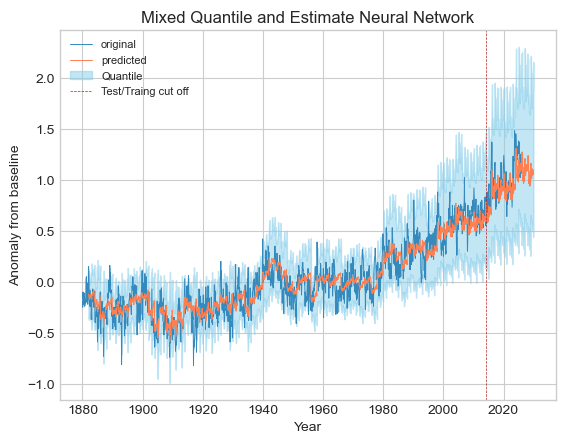

In [26]:
## This is the same plot, but after backtransforming and true future prediction. 
plt.plot(flat_df.time, backor, color = "#348ABD", linewidth = .7, label = "original")
plt.plot(time_index_future,pred_future.Estimate, linewidth = .7, color = "coral", label = "predicted")
plt.fill_between(time_index_future,pred_future.Upper, pred_future.Lower, color = "skyblue", alpha = .5, label = "Quantile")
plt.title("Mixed Quantile and Estimate Neural Network")
plt.axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
                color = "firebrick", linewidth = .5, linestyle = "--") 
plt.ylabel("Anomaly from baseline")
plt.xlabel("Year")
plt.legend(fontsize=8)
plt.show()


## LSTM (Long Short-Term Memory) Neural Network. 
This and RNN (recurrent Neural Networks) have better properties of incorporating old data for prediction than the sliding window. As the sliding window can only look at the lenght of the input data, these models can apparently look further into the past to make predictions. And while I am not entirely certain how they are working, I attempted to build one below. 

In [27]:
## Resetting the SEED
torch.manual_seed(SEED)

class LSTMWindow(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, output_size=24): #All of the changes that can be made occur here?
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True) # This does not seem very mutable
        self.fc = nn.Linear(hidden_size, output_size) # No activation after this!

    def forward(self, x):
        # x is [1, 24, 1]
        out, _ = self.lstm(x)
        # Only take the last step's hidden state
        out = self.fc(out[:, -1, :]) 
        return out

LSmodel = LSTMWindow()

In [28]:
## Choose loss and optimizer
criterion = nn.MSELoss()
# criterion = nn.SmoothL1Loss() #Huber Loss
optimizer = optim.Adam(LSmodel.parameters(), lr=.001)

## Inside the training loop
LSmodel.train()

## Begin for loop This is the actual NN loop. 
for epoch in range(70):
    running_loss = 0.0
    pred = []

    # need to create an outside value for past lag and lead. 
    start = prm.start
    length = prm.length
    lead = prm.lead

    # I can still use the sliding window to work through the data, but I am not certain this is actually ideal for LSTM. 
    for i in range(0, len(flat_df.original) - lead - length - prm.test, lead):
        lags, leads = window(flat_df.original, i, length, lead)
    
        # MLP used: lags.view(1, -1) -> (1, 24)
        # LSTM needs: (Batch, Seq_Length, Feature_count) -> (1, 24, 1)
        lags_dim = lags.view(1, length, 1) 
        leads_dim = leads.view(1, -1) # Target stays (1, 24)
    
        ## Forward pass
        optimizer.zero_grad()
        outputs = LSmodel(lags_dim)
        loss = criterion(outputs, leads_dim)

        ## Backward pass with Gradient Clipping
        loss.backward()
        torch.nn.utils.clip_grad_norm_(LSmodel.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

In [29]:
## finding predictions
LSmodel.eval()
pred = []

with torch.no_grad():
    for i in range(0,len(flat_df.original) - prm.length, prm.lead):  
        lags, __ = window(flat_df.original, i, prm.length, prm.lead)
        lags_dim = lags.view(1, prm.length, 1) # the shape of the data is very picky. 
        output = LSmodel(lags_dim)
        pred.append(output.flatten()) 
        # I think this is spitting out batches of 24 and needs the flatten to list the values. The flattening 
        
# Condensing the predictions into one array and backtransforming it
# It should be set at -24 as we do not want to forecast the first 2 years. 
LS_prediction = (np.concatenate(pred))
len(LS_prediction) + 24

1752

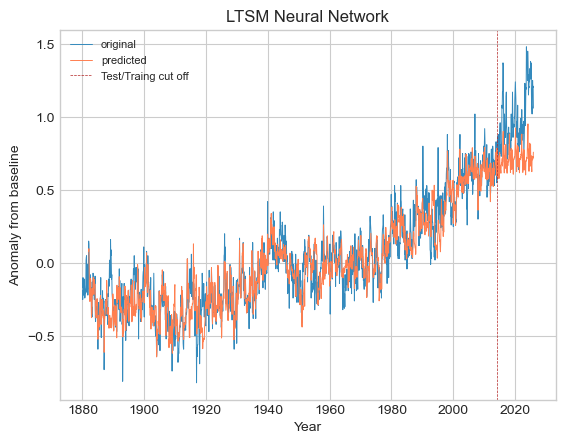

In [30]:
## With backtransforming
backor = backtransform(flat_df.original)
backpr = backtransform(LS_prediction)

plt.plot(flat_df.time, backor, color = "#348ABD", linewidth = .7, label = "original")
plt.plot(flat_df.time.loc[24:1752], backpr, color = "coral", linewidth = .7, label = "predicted") 
plt.title("LTSM Neural Network")
plt.axvline(x = pd.to_datetime("2014-01-01"), label = "Test/Traing cut off", 
                color = "firebrick", linewidth = .5, linestyle = "--") 
plt.ylabel("Anomaly from baseline")
plt.xlabel("Year")
plt.legend(fontsize=8)
plt.show()
plt.show()

## Comments:
The model looks like it is doing about the same as the sliding window. I am curious if there is a big advantage of this model, or if the data is simply not big enough for us to see a difference. I would like to run this many times to see what type of intervals and losses it produces. I will say that after a few runs, the model does tend to underpredict the anomaly, and can produce wider changes than the sliding window. It may be that it can be much better optimized for these data, but I do not understand the framework enough to correctly adjust it. One place the model suffers is that it wants to recreate the earlier years, and does not recognize the significant change in the later years versus the past.

In [31]:
import json
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import TimeSeriesSplit

# Assumes flat_df.original is already standardized monthly series
# Assumes backtransform() already exists
# Assumes prm.length = 24 and prm.lead = 24
torch.manual_seed(SEED)

series = pd.Series(flat_df.original).reset_index(drop=True)
time_index = pd.Series(flat_df.time).reset_index(drop=True)

def make_windows_fold(series, length=24, lead=24, step=24):
    X, y = [], []
    last_start = len(series) - length - lead
    for i in range(0, last_start + 1, step):
        x = series.iloc[i:i + length].values.astype(np.float32)
        target = series.iloc[i + length:i + length + lead].values.astype(np.float32)
        X.append(x)
        y.append(target)
    return np.array(X), np.array(y)


def fit_sliding_window_model(train_series, learning=0.001, epoch_max=40):
    X_train, y_train = make_windows_fold(
        train_series,
        length=prm.length,
        lead=prm.lead,
        step=prm.lead
    )

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)

    model = SlidingWindow()
    criterion = nn.SmoothL1Loss()
    optimizer = optim.Adam(model.parameters(), lr=learning)

    model.train()
    for epoch in range(epoch_max):
        for j in range(len(X_train_t)):
            x_batch = X_train_t[j].view(1, -1)
            y_batch = y_train_t[j].view(1, -1)

            optimizer.zero_grad()
            output = model(x_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

    return model

def recursive_forecast(model, history, steps, input_length=24, block_size=24):
    history_vals = history.astype(np.float32).tolist()
    preds = []

    model.eval()
    with torch.no_grad():
        blocks = math.ceil(steps / block_size)
        for _ in range(blocks):
            last_lags = torch.tensor(
                np.array(history_vals[-input_length:], dtype=np.float32),
                dtype=torch.float32
            ).view(1, -1)

            block_pred = model(last_lags).cpu().numpy().ravel().astype(np.float32)
            preds.extend(block_pred.tolist())
            history_vals.extend(block_pred.tolist())

    return np.array(preds[:steps], dtype=np.float32)

def run_nn_cv_json(learning=0.001, epoch_max=40, json_path="nn_cv_results.json"):
    tscv = TimeSeriesSplit(n_splits=5, test_size=24)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(series), 1):
        fold_train = series.iloc[train_idx].reset_index(drop=True)
        fold_val = series.iloc[val_idx].reset_index(drop=True)
        fold_val_time = time_index.iloc[val_idx].reset_index(drop=True)

        model = fit_sliding_window_model(
            fold_train,
            learning=learning,
            epoch_max=epoch_max
        )

        pred_std = recursive_forecast(
            model,
            fold_train.values,
            steps=len(fold_val),
            input_length=prm.length,
            block_size=prm.lead
        )

        actual_std = fold_val.values.astype(np.float32)

        pred = backtransform(pred_std)
        actual = backtransform(actual_std)

        mse = float(np.mean((actual - pred) ** 2))
        mae = float(np.mean(np.abs(actual - pred)))

        fold_results.append({
            "fold": fold,
            "train_start": str(time_index.iloc[train_idx[0]]),
            "train_end": str(time_index.iloc[train_idx[-1]]),
            "val_start": str(fold_val_time.iloc[0]),
            "val_end": str(fold_val_time.iloc[-1]),
            "mse": mse,
            "mae": mae,
            "actual": actual.tolist(),
            "predicted": pred.tolist()
        })

    final_train = series.iloc[:-prm.test].reset_index(drop=True)
    final_holdout = series.iloc[-prm.test:].reset_index(drop=True)

    final_model = fit_sliding_window_model(
        final_train,
        learning=learning,
        epoch_max=epoch_max
    )

    holdout_pred_std = recursive_forecast(
        final_model,
        final_train.values,
        steps=prm.test,
        input_length=prm.length,
        block_size=prm.lead
    )

    holdout_actual = backtransform(final_holdout.values.astype(np.float32))
    holdout_pred = backtransform(holdout_pred_std)

    summary = {
        "model_name": "SlidingWindow_NN",
        "cv_scheme": "TimeSeriesSplit(n_splits=5, test_size=24)",
        "input_length": int(prm.length),
        "forecast_horizon": int(prm.test),
        "learning_rate": float(learning),
        "epochs": int(epoch_max),
        "mean_mse": float(np.mean([x["mse"] for x in fold_results])),
        "std_mse": float(np.std([x["mse"] for x in fold_results], ddof=1)),
        "mean_mae": float(np.mean([x["mae"] for x in fold_results])),
        "std_mae": float(np.std([x["mae"] for x in fold_results], ddof=1)),
        "cv_errors": [x["mse"] for x in fold_results],
        "holdout_actual": holdout_actual.tolist(),
        "holdout_pred": holdout_pred.tolist(),
        "folds": fold_results
    }

    with open(json_path, "w") as f:
        json.dump(summary, f, indent=2)

    print(f"Saved {json_path}")
    print(f"Mean MSE: {summary['mean_mse']:.4f}")
    print(f"Mean MAE: {summary['mean_mae']:.4f}")
    print(f"Holdout horizon: {len(summary['holdout_pred'])}")

    return summary

# Run with your tuned values if you want to keep them fixed
nn_cv_summary = run_nn_cv_json(
    learning=best_learning if 'best_learning' in globals() else 0.001,
    epoch_max=best_epoch if 'best_epoch' in globals() else 40,
    json_path="nn_cv_results.json"
)

Saved nn_cv_results.json
Mean MSE: 0.0628
Mean MAE: 0.2010
Holdout horizon: 120
